This notebook evaluates the trained SVM spam detection model.

In [3]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
test_data = pd.read_csv("../data/svm_test_data.csv")

print("Test data shape:", test_data.shape)
test_data.head()

Test data shape: (1009, 2)


,clean_message,label_encoded
0,good need receipt well done yes please tell nu...,0
1,idc get weaseling way shit twice row,0
2,free call sir,0
3,hey want crave miss need love ahmad saeed al h...,0
4,co shopping wif darren jus called ask wat pres...,0


In [5]:
print(test_data.columns.tolist())

['clean_message', 'label_encoded']


In [6]:
tfidf_vectorizer = joblib.load("../models/tfidf_vectorizer.pkl")
svm_model = joblib.load("../models/svm_model.pkl")

print("TF-IDF vectorizer loaded successfully.")
print("SVM model loaded successfully.")

TF-IDF vectorizer loaded successfully.
SVM model loaded successfully.


In [7]:
X_test_text = test_data["clean_message"].fillna("")
y_test = test_data["label_encoded"]

X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

print("Test TF-IDF shape -", X_test_tfidf.shape)
print("Test labels shape -", y_test.shape)

Test TF-IDF shape - (1009, 5000)
Test labels shape - (1009,)


In [8]:
y_pred = svm_model.predict(X_test_tfidf)

print("Predictions completed.")
print("Number of prediction :", len(y_pred))

Predictions completed.
Number of prediction : 1009


In [9]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("SVM Evaluation Results")
print("-" * 30)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

SVM Evaluation Results
------------------------------
Accuracy : 0.9841
Precision: 0.9808
Recall   : 0.8793
F1 Score : 0.9273


In above code we can see those things,

Accuracy: overall correct predictions
Precision: how many predicted spam messages were actually spam
Recall: how many real spam messages the model detected
F1 score: balance between precision and recall

In [10]:
print("Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Ham", "Spam"],
        digits=4
    )
)

Classification Report:

              precision    recall  f1-score   support

         Ham     0.9845    0.9978    0.9911       893
        Spam     0.9808    0.8793    0.9273       116

    accuracy                         0.9841      1009
   macro avg     0.9826    0.9385    0.9592      1009
weighted avg     0.9841    0.9841    0.9838      1009



In [11]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[891   2]
 [ 14 102]]


In this project,

True Negative: ham correctly predicted as ham
False Positive: ham incorrectly predicted as spam
False Negative: spam incorrectly predicted as ham
True Positive: spam correctly predicted as spam

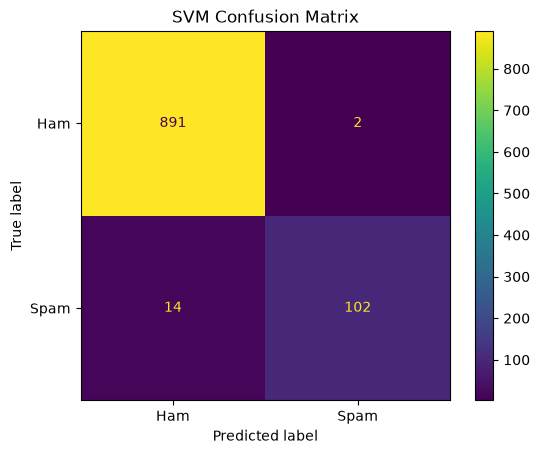

In [12]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
)

disp.plot(values_format="d")
plt.title("SVM Confusion Matrix")
plt.show()

In [13]:
if hasattr(svm_model, "decision_function"):
    y_scores = svm_model.decision_function(X_test_tfidf)
    roc_auc = roc_auc_score(y_test, y_scores)

    print(f"ROC-AUC Score: {roc_auc:.4f}")
else:
    print("Decision scores are not available for this model.")

ROC-AUC Score: 0.9943


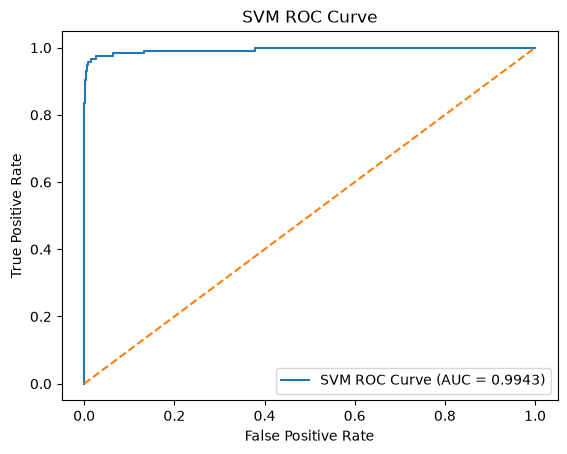

In [14]:
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

plt.figure()
plt.plot(fpr, tpr, label=f"SVM ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")
plt.legend()
plt.show()

In [15]:
results = pd.DataFrame({
    "message": X_test_text.reset_index(drop=True),
    "actual": y_test.reset_index(drop=True),
    "predicted": y_pred
})

incorrect_predictions = results[
    results["actual"] != results["predicted"]
]

print("incorrect predictions:", len(incorrect_predictions))

incorrect_predictions.head(20)

incorrect predictions: 16


,message,actual,predicted
51,hi sue year old work lapdancer love sex text l...,1,0
76,call freephone,1,0
295,current leading bid pause auction send custome...,1,0
311,call germany penny per minute call fixed line ...,1,0
474,waiting machan call free,0,1
482,realize year thousand old lady running around ...,1,0
493,monthly password wap mobsi com use wap phone pc,1,0
561,sm ac sun post hello seem cool wanted say hi h...,1,0
565,romcapspam everyone around responding well pre...,1,0
605,heard call night knickers make beg like last t...,1,0


In [16]:
false_positives = results[
    (results["actual"] == 0) &
    (results["predicted"] == 1)
]

false_negatives = results[
    (results["actual"] == 1) &
    (results["predicted"] == 0)
]

print("False positives:", len(false_positives))
print("False negatives:", len(false_negatives))

False positives: 2
False negatives: 14


In [17]:
false_positives.head(10)

,message,actual,predicted
474,waiting machan call free,0,1
1004,receive msg,0,1


In [18]:
false_negatives.head(10)

,message,actual,predicted
51,hi sue year old work lapdancer love sex text l...,1,0
76,call freephone,1,0
295,current leading bid pause auction send custome...,1,0
311,call germany penny per minute call fixed line ...,1,0
482,realize year thousand old lady running around ...,1,0
493,monthly password wap mobsi com use wap phone pc,1,0
561,sm ac sun post hello seem cool wanted say hi h...,1,0
565,romcapspam everyone around responding well pre...,1,0
605,heard call night knickers make beg like last t...,1,0
700,accordingly repeat text word ok mobile phone send,1,0


In [19]:
os.makedirs("../results", exist_ok=True)

metrics_df = pd.DataFrame({
    "Model": ["SVM"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1_Score": [f1],
    "ROC_AUC": [roc_auc]
})

metrics_df.to_csv(
    "../results/svm_evaluation_metrics.csv",
    index=False
)

results.to_csv(
    "../results/svm_predictions.csv",
    index=False
)

print("Evaluation metrics saved.")
print("Prediction saved.")

Evaluation metrics saved.
Prediction saved.
